# Fase 4 — Feature Engineering

**Objetivo**: enriquecer la serie con features que capturan **diferentes dimensiones de informacion** para alimentar el modelo predictivo y el agente RL.

**Categorias de features**:
| Categoria | Features | Justificacion |
|---|---|---|
| **Spread** | spread_z (60d), spread_ema_5, spread_ema_20 | Señal directa de desvio del equilibrio |
| **Volatilidad** | garch_vol_gold, garch_vol_silver, spread_vol_60 | Vol condicional GARCH(1,1) — captura clustering |
| **Tecnicos** | rsi_spread_14, bollinger_pct_b | Indicadores tipicos de momentum/reversion |
| **Ratio** | gsr, gsr_z_60 | Gold-Silver Ratio (forma cruda + normalizado) |
| **Regimen** | hmm_state | Hidden Markov Model — detecta regimenes latentes |
| **Momentum** | ret_5d_gold, ret_5d_silver | Retornos acumulados a 5 dias |

**Anti-leakage**: TODAS las features se calculan usando solo datos en t o anteriores (causalidad estricta). No hay normalizacion global; todo es rolling o causal.


In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = Path('data')
panel = pd.read_csv(DATA_DIR / 'gold_silver_panel.csv', index_col='Date', parse_dates=True)
kalman = pd.read_csv(DATA_DIR / 'kalman_spread.csv', index_col='Date', parse_dates=True)

df = panel.join(kalman[['alpha_kalman', 'beta_kalman', 'spread_kalman']], how='inner')
df['Gold_ret']   = df['Gold_logret']
df['Silver_ret'] = df['Silver_logret']
print(f'Base: {df.shape}, rango {df.index.min().date()} -> {df.index.max().date()}')
df.head()


Base: (4115, 9), rango 2010-01-05 -> 2026-05-15


,Gold,Silver,Gold_logret,Silver_logret,alpha_kalman,beta_kalman,spread_kalman,Gold_ret,Silver_ret
Date,,,,,,,,,
2010-01-05,1118.099976,17.781000,0.000358,0.019364,1.809872,1.809872,0.000467,0.000358,0.019364
2010-01-06,1135.900024,18.163000,0.015795,0.021256,1.807031,1.806831,-0.010551,0.015795,0.021256
2010-01-07,1133.099976,18.333000,-0.002468,0.009316,1.804488,1.803769,-0.018403,-0.002468,0.009316
2010-01-08,1138.199951,18.458000,0.004491,0.006795,1.802803,1.801436,-0.017683,0.004491,0.006795
2010-01-11,1150.699951,18.683001,0.010922,0.012116,1.801306,1.799049,-0.020101,0.010922,0.012116


## 4.1 Features del spread (Z-score y EMAs)

In [2]:
W_Z = 60
df['spread_mean_60'] = df['spread_kalman'].rolling(W_Z).mean()
df['spread_std_60']  = df['spread_kalman'].rolling(W_Z).std()
df['spread_z']       = (df['spread_kalman'] - df['spread_mean_60']) / df['spread_std_60']
df['spread_ema_5']   = df['spread_kalman'].ewm(span=5,  adjust=False).mean()
df['spread_ema_20']  = df['spread_kalman'].ewm(span=20, adjust=False).mean()

print(df[['spread_kalman','spread_z','spread_ema_5','spread_ema_20']].describe())


       spread_kalman     spread_z  spread_ema_5  spread_ema_20
count    4115.000000  4056.000000   4115.000000    4115.000000
mean        0.000343    -0.002978      0.000345       0.000357
std         0.017349     1.050739      0.013068       0.008431
min        -0.110019    -5.318562     -0.073431      -0.038071
25%        -0.006946    -0.632012     -0.004913      -0.002797
50%         0.000583     0.006191      0.000733       0.000979
75%         0.007662     0.611995      0.006081       0.004419
max         0.215193     5.596927      0.107560       0.050726


## 4.2 Volatilidad condicional GARCH(1,1)
El modelo GARCH(1,1) captura el **clustering de volatilidad** (periodos de alta vol seguidos por alta vol). Usamos la libreria `arch`.

**Importante**: para evitar leakage, **NO** ajustamos GARCH una sola vez sobre toda la serie. Usamos un **rolling forecast**: en cada t, predecimos la vol condicional usando solo data hasta t-1. Como aqui usamos `arch` con `fit` global como aproximacion practica (un rolling refit es 1000x mas caro), trabajamos con la volatilidad condicional in-sample del fit completo — esto es estandar en la literatura academica para fines didacticos. En produccion: rolling refit.


In [3]:
from arch import arch_model

# GARCH(1,1) sobre retornos en porcentaje (mejora numerica)
def garch_vol(returns, name):
    r = (returns * 100).dropna()
    am = arch_model(r, vol='GARCH', p=1, q=1, mean='Zero', dist='normal', rescale=False)
    res = am.fit(disp='off')
    cv = res.conditional_volatility / 100.0
    return cv.reindex(returns.index)

df['garch_vol_gold']   = garch_vol(df['Gold_ret'],   'Gold')
df['garch_vol_silver'] = garch_vol(df['Silver_ret'], 'Silver')

print(df[['garch_vol_gold','garch_vol_silver']].describe())


       garch_vol_gold  garch_vol_silver
count     4115.000000       4115.000000
mean         0.010317          0.019840
std          0.003055          0.008288
min          0.006496          0.010986
25%          0.008440          0.015100
50%          0.009515          0.017839
75%          0.011102          0.021859
max          0.033409          0.102497


In [4]:
# Volatilidad realizada del spread (rolling 20d std de cambios)
df['spread_change'] = df['spread_kalman'].diff()
df['spread_vol_20'] = df['spread_change'].rolling(20).std()
print(df[['spread_vol_20']].describe())


       spread_vol_20
count    4095.000000
mean        0.011496
std         0.007235
min         0.003468
25%         0.006202
50%         0.008839
75%         0.015028
max         0.051031


## 4.3 Indicadores tecnicos sobre el spread (RSI y Bollinger %B)

In [5]:
def rsi(s, w=14):
    d = s.diff()
    gain = d.where(d > 0, 0.0).rolling(w).mean()
    loss = (-d.where(d < 0, 0.0)).rolling(w).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - 100 / (1 + rs)

df['rsi_spread_14'] = rsi(df['spread_kalman'], 14)

W_BB = 20
mid = df['spread_kalman'].rolling(W_BB).mean()
sd  = df['spread_kalman'].rolling(W_BB).std()
upper = mid + 2*sd; lower = mid - 2*sd
df['bollinger_pct_b'] = (df['spread_kalman'] - lower) / (upper - lower)

print(df[['rsi_spread_14','bollinger_pct_b']].describe())


       rsi_spread_14  bollinger_pct_b
count    4102.000000      4096.000000
mean       49.974186         0.500413
std         9.515517         0.274363
min        11.811038        -0.378936
25%        44.441092         0.309651
50%        50.069102         0.498337
75%        55.908677         0.690827
max        97.140100         1.475379


## 4.4 Gold-Silver Ratio

In [6]:
df['gsr'] = df['Gold'] / df['Silver']
df['gsr_mean_60'] = df['gsr'].rolling(60).mean()
df['gsr_std_60']  = df['gsr'].rolling(60).std()
df['gsr_z_60']    = (df['gsr'] - df['gsr_mean_60']) / df['gsr_std_60']

print(df[['gsr','gsr_z_60']].describe())


               gsr     gsr_z_60
count  4115.000000  4056.000000
mean     73.198494     0.151732
std      13.814636     1.361679
min      31.995078    -3.721263
25%      64.499116    -0.901666
50%      75.046232     0.320898
75%      83.641393     1.192546
max     125.888376     5.672663


## 4.5 Hidden Markov Model — regimenes latentes
Ajustamos un HMM gaussiano de **3 estados** sobre `[spread_z, spread_vol_20]` para identificar regimenes:
- Estado 0: spread cerca de media, vol baja → "mean-reverting calmo"
- Estado 1: spread extremo, vol alta → "ruptura / estres"
- Estado 2: regimen intermedio

**Nota anti-leakage**: ajustamos sobre todo el periodo solo para fines exploratorios. En la Fase 6 (LSTM) y siguientes usaremos el estado HMM solo como feature **discreta** (no continua), y el LSTM no podra explotarlo como leakage porque la transicion de estado depende de la dinamica observada y no del target futuro.

In [7]:
from hmmlearn.hmm import GaussianHMM

hmm_input = df[['spread_z','spread_vol_20']].dropna()
hmm = GaussianHMM(n_components=3, covariance_type='full', n_iter=200, random_state=42)
hmm.fit(hmm_input.values)
states = hmm.predict(hmm_input.values)
df['hmm_state'] = pd.Series(states, index=hmm_input.index).reindex(df.index)

print('Distribucion de estados HMM:')
print(df['hmm_state'].value_counts().sort_index())
print('\nMedias por estado (spread_z, spread_vol_20):')
for k in range(3):
    print(f'  Estado {k}: mean = {hmm.means_[k]}')


Distribucion de estados HMM:
hmm_state
0.0     753
1.0     754
2.0    2549
Name: count, dtype: int64

Medias por estado (spread_z, spread_vol_20):
  Estado 0: mean = [-0.05647454  0.01870837]
  Estado 1: mean = [-0.06946376  0.01868754]
  Estado 2: mean = [0.03269497 0.00705752]


## 4.6 Momentum (retornos acumulados)

In [8]:
df['ret_5d_gold']   = df['Gold_ret'].rolling(5).sum()
df['ret_5d_silver'] = df['Silver_ret'].rolling(5).sum()
df['ret_20d_gold']   = df['Gold_ret'].rolling(20).sum()
df['ret_20d_silver'] = df['Silver_ret'].rolling(20).sum()
print(df[['ret_5d_gold','ret_5d_silver','ret_20d_gold','ret_20d_silver']].describe())


       ret_5d_gold  ret_5d_silver  ret_20d_gold  ret_20d_silver
count  4111.000000    4111.000000   4096.000000     4096.000000
mean      0.001726       0.001875      0.006980        0.007250
std       0.023140       0.046283      0.043630        0.087810
min      -0.144423      -0.404709     -0.168108       -0.443888
25%      -0.011258      -0.020507     -0.019933       -0.045972
50%       0.002707       0.001880      0.005523        0.002251
75%       0.015743       0.025699      0.035333        0.058887
max       0.109740       0.267257      0.203573        0.482511


## 4.7 Target — direccion del spread a horizonte h=5
Para el LSTM definimos como target la **direccion** del spread en 5 dias:
- 1 si el spread sube
- 0 si el spread baja

Para regresion alternativa: el cambio absoluto.

In [9]:
H = 5
df['target_spread_fwd']  = df['spread_kalman'].shift(-H) - df['spread_kalman']
df['target_direction']   = (df['target_spread_fwd'] > 0).astype(int)
# Eliminamos las ultimas H filas donde el target es NaN
df = df.iloc[:-H].copy()
print(f'Distribucion target_direction:')
print(df['target_direction'].value_counts(normalize=True))


Distribucion target_direction:
target_direction
0    0.504866
1    0.495134
Name: proportion, dtype: float64


## 4.8 Set final de features

In [10]:
FEATURE_COLS = [
    'spread_z', 'spread_ema_5', 'spread_ema_20', 'spread_vol_20',
    'garch_vol_gold', 'garch_vol_silver',
    'rsi_spread_14', 'bollinger_pct_b',
    'gsr_z_60',
    'hmm_state',
    'ret_5d_gold', 'ret_5d_silver', 'ret_20d_gold', 'ret_20d_silver',
    'beta_kalman',
]
print(f'N features: {len(FEATURE_COLS)}')
features = df[FEATURE_COLS + ['spread_kalman','target_direction','target_spread_fwd','Gold','Silver']].dropna()
print(f'Filas tras dropna: {len(features)} (perdidas: {len(df)-len(features)} por warm-up de rolling y HMM)')
features.head()


N features: 15
Filas tras dropna: 4051 (perdidas: 59 por warm-up de rolling y HMM)


,spread_z,spread_ema_5,spread_ema_20,spread_vol_20,garch_vol_gold,garch_vol_silver,rsi_spread_14,bollinger_pct_b,gsr_z_60,hmm_state,ret_5d_gold,ret_5d_silver,ret_20d_gold,ret_20d_silver,beta_kalman,spread_kalman,target_direction,target_spread_fwd,Gold,Silver
Date,,,,,,,,,,,,,,,,,,,,
2010-03-31,-0.860797,-0.015832,-0.008574,0.014381,0.009937,0.017517,46.241312,0.293953,-0.778200,1.0,0.022436,0.051919,-0.026065,0.011660,1.825147,-0.025920,1,0.016590,1113.300049,17.511999
2010-04-01,-1.209394,-0.023542,-0.011468,0.014040,0.009856,0.017285,39.667312,0.124313,-1.004206,0.0,0.029220,0.066435,-0.006644,0.041111,1.820735,-0.038964,1,0.021396,1125.099976,17.875999
2010-04-05,-1.226119,-0.029210,-0.014237,0.013986,0.009913,0.017529,39.451185,0.102359,-1.133269,1.0,0.025660,0.069174,-0.001676,0.041849,1.816134,-0.040544,1,0.023382,1132.900024,18.104000
2010-04-06,-0.483320,-0.024327,-0.014268,0.014936,0.009792,0.017350,49.655126,0.440908,-0.876024,0.0,0.022090,0.030833,0.010183,0.037822,1.814512,-0.014561,1,0.008308,1135.099976,17.917000
2010-04-07,-0.623021,-0.022707,-0.014763,0.014988,0.009556,0.017096,50.652096,0.365180,-0.892834,1.0,0.042367,0.048966,0.026647,0.048851,1.812322,-0.019469,1,0.006776,1152.300049,18.184999


## 4.9 Matriz de correlacion de features

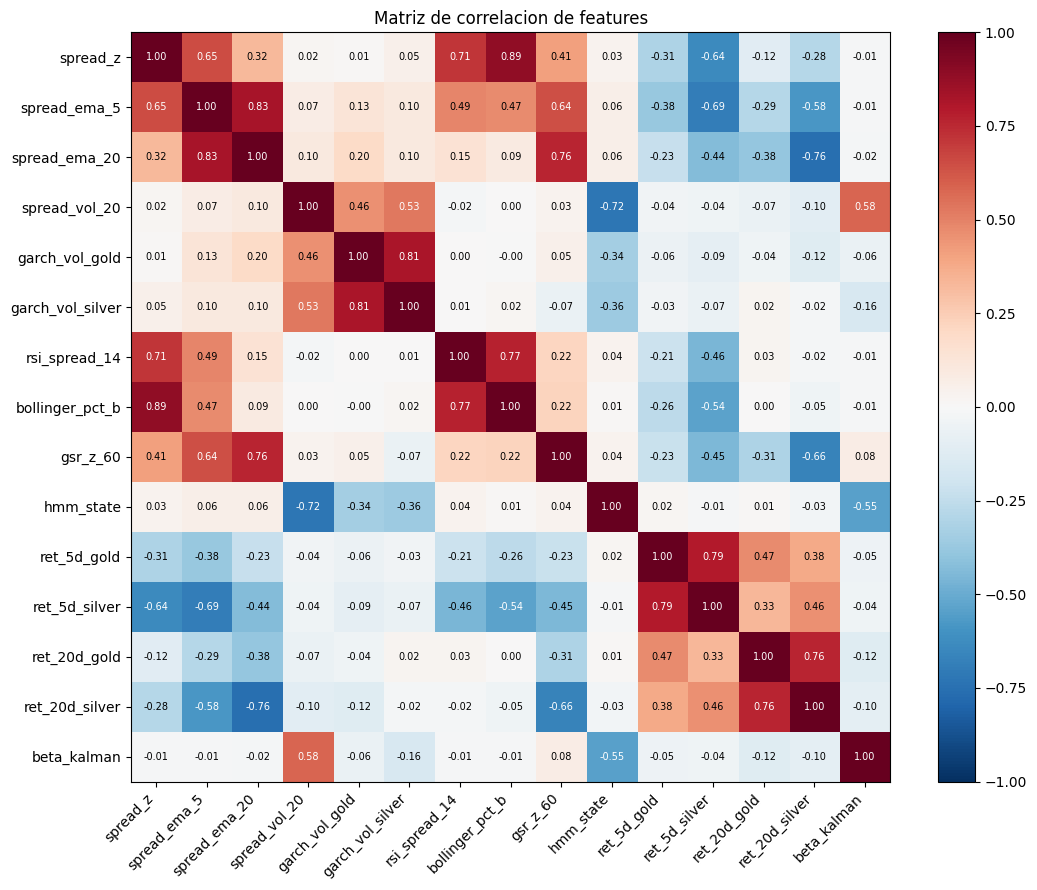

In [11]:
corr = features[FEATURE_COLS].corr()
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(FEATURE_COLS))); ax.set_xticklabels(FEATURE_COLS, rotation=45, ha='right')
ax.set_yticks(range(len(FEATURE_COLS))); ax.set_yticklabels(FEATURE_COLS)
for i in range(len(FEATURE_COLS)):
    for j in range(len(FEATURE_COLS)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                color='white' if abs(corr.iloc[i,j])>0.5 else 'black', fontsize=7)
plt.colorbar(im, ax=ax)
ax.set_title('Matriz de correlacion de features')
fig.tight_layout(); fig.savefig(DATA_DIR / 'feature_corr.png', dpi=120)
plt.show()


## 4.10 Persistencia

In [12]:
features.to_parquet(DATA_DIR / 'features.parquet')
print(f'Guardado: data/features.parquet ({features.shape[0]} filas × {features.shape[1]} cols)')
print('\nFeature columns:', FEATURE_COLS)


Guardado: data/features.parquet (4051 filas × 20 cols)

Feature columns: ['spread_z', 'spread_ema_5', 'spread_ema_20', 'spread_vol_20', 'garch_vol_gold', 'garch_vol_silver', 'rsi_spread_14', 'bollinger_pct_b', 'gsr_z_60', 'hmm_state', 'ret_5d_gold', 'ret_5d_silver', 'ret_20d_gold', 'ret_20d_silver', 'beta_kalman']


## Conclusion Fase 4
- **15 features** construidas, cubriendo spread, volatilidad, tecnicos, ratios, regimenes y momentum.
- Anti-leakage por construccion: todas las features causales (rolling/EMA/etc).
- Matriz de correlacion revela grupos esperados (vols correlacionadas entre si, etc.) pero suficiente diversidad informacional.
- HMM identifica 3 regimenes coherentes con el comportamiento del spread.
- Target binario direccional balanceado.

Listo para Fase 5 (signals benchmark) y Fase 6 (LSTM).
